In [1]:
from src.sam3.samgeo3 import SamGeo3
from typing import List
from src.sam3.samgeo3 import PredictionResult
from matplotlib import pyplot as plt
import rasterio


In [2]:
sam = SamGeo3()

img_path_1 = "data/example/netivot1.tif"
img_path_2 = "data/example/netivot2.tif"

Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

The OrderedVocab you are attempting to save contains holes for indices [1], your vocabulary could be corrupted !
The OrderedVocab you are attempting to save contains holes for indices [1], your vocabulary could be corrupted !


In [3]:
# --- EXAMPLE 1: Text Prompt ---
# print("--- Running Example 1: Text Prompt ---")
# text_results = sam.predict_batch(
#     images=[img_path_1, img_path_2], prompts="red_roof", batch_size=2
# )

# gdf_text = sam.results_to_gdf(text_results)
# if gdf_text is not None:
#     print(
#         f"Text Prompt Example: Created GeoDataFrame with {len(gdf_text)} features."
#     )

# --- EXAMPLE 2: Bounding Box Prompt ---
print("\n--- Running Example 2: Bounding Box Prompt ---")



box_results = sam.predict_batch(
    images=[img_path_1],
    input_boxes=[[[200,200,500,500]]],  # Batch size 1, 1 box per image
    batch_size=1,
)

gdf_box = sam.results_to_gdf(box_results)
if gdf_box is not None:
    print(f"Box Prompt Example: Created GeoDataFrame with {len(gdf_box)} features.")



--- Running Example 2: Bounding Box Prompt ---


SAM3 Batch: 100%|██████████| 1/1 [00:03<00:00,  3.15s/it]


Box Prompt Example: Created GeoDataFrame with 720 features.


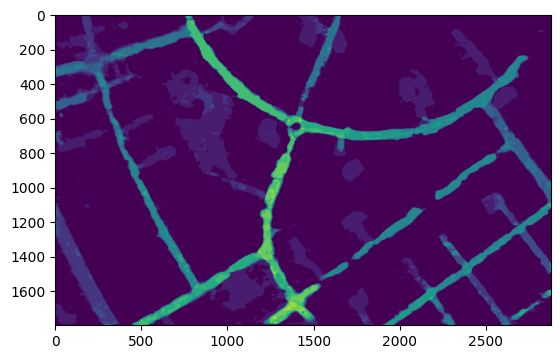

In [4]:
plt.imshow(sum(box_results['netivot1.tif']['masks']))

In [6]:
box_results['netivot1.tif']['masks']

[]

In [3]:
from shapely import MultiPolygon

MultiPolygon(gdf[gdf['image_id']==gdf.iloc[0,1]].geometry.to_list())

TypeError: 'NoneType' object is not subscriptable

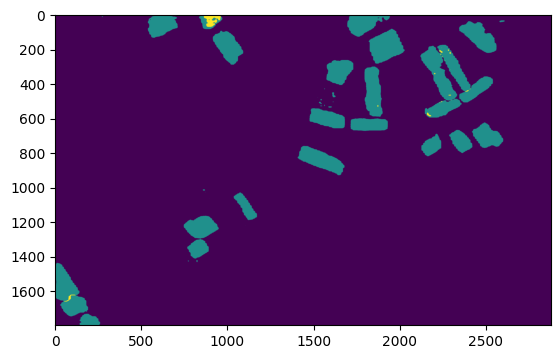

In [5]:
plt.imshow(sum(text_results['netivot1.tif']['masks']))